# Generator Diversity Coverage Plot

Edit the config cell, then rerun the notebook to regenerate a publication-style coverage-vs-sample-count figure from `regex_generator_diversity_coverage_benchmark.py` results.

In [18]:
from collections import defaultdict
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Input from the benchmark. This can be either the JSONL stream or the summary JSON.
RESULTS_PATH = Path("coverage_outputs/diversity_email_validator_package.jsonl")
if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("regex_positive_generator/benchmarks") / RESULTS_PATH

# Figure output.
OUTPUT_PATH = Path("coverage_outputs/regex_generator_diversity_coverage_curve_custom.png")
OUTPUT_PDF_PATH = Path("coverage_outputs/regex_generator_diversity_coverage_curve_custom.pdf")

# Plot controls.
METRICS = ["code_coverage"]
INCLUDE_ERROR_MARKERS = False
ONLY_OK_IN_LINES = True
MAX_N = None  # e.g. 50000 to hide larger n values
MIN_N = None

# Optional manual tool order and display names.
TOOL_ORDER = [
    "RegexInstantiator",
    "exrex",
    "Xeger",
    "EGRET",
    "Generex",
    "RgxGen",
    "RandExp.js",
    "MutRex",
]
TOOL_LABELS = {
    "RegexInstantiator": "MATCHMAKER",
    "exrex": "exrex",
    "Xeger": "Xeger",
    "EGRET": "EGRET",
    "Generex": "Generex",
    "RgxGen": "RgxGen",
    "RandExp.js": "RandExp.js",
    "MutRex": "MutRex",
}

# Colors are deliberately high-contrast for paper figures.
TOOL_COLORS = {
    "RegexInstantiator": "#1f77b4",
    "exrex": "#d62728",
    "Xeger": "#2ca02c",
    "EGRET": "#9467bd",
    "Generex": "#ff7f0e",
    "RgxGen": "#8c564b",
    "RandExp.js": "#17becf",
    "MutRex": "#7f7f7f",
}
TOOL_MARKERS = {
    "RegexInstantiator": "o",
    "exrex": "s",
    "Xeger": "^",
    "EGRET": "D",
    "Generex": "P",
    "RgxGen": "X",
    "RandExp.js": "v",
    "MutRex": "*",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [19]:
def load_results(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Could not find results file: {path.resolve()}")

    if path.suffix == ".jsonl":
        rows = []
        with path.open("r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if line:
                    rows.append(json.loads(line))
        return rows

    with path.open("r", encoding="utf-8") as fh:
        payload = json.load(fh)
    return payload.get("results", [])


def filtered_rows(rows):
    kept = []
    for row in rows:
        n = int(row["samples_per_class"])
        if MIN_N is not None and n < MIN_N:
            continue
        if MAX_N is not None and n > MAX_N:
            continue
        kept.append(row)
    return kept


rows = filtered_rows(load_results(RESULTS_PATH))
if not rows:
    raise RuntimeError("No rows after filtering.")

target_names = sorted({row.get("target", "") for row in rows})
statuses = defaultdict(int)
for row in rows:
    statuses[row.get("status", "unknown")] += 1

print(f"Loaded {len(rows)} rows from {RESULTS_PATH}")
print(f"Targets: {', '.join(target_names)}")
print(f"Statuses: {dict(statuses)}")

Loaded 64 rows from coverage_outputs/diversity_email_validator_package.jsonl
Targets: email_validator_package
Statuses: {'ok': 31, 'timeout': 1, 'error': 32}


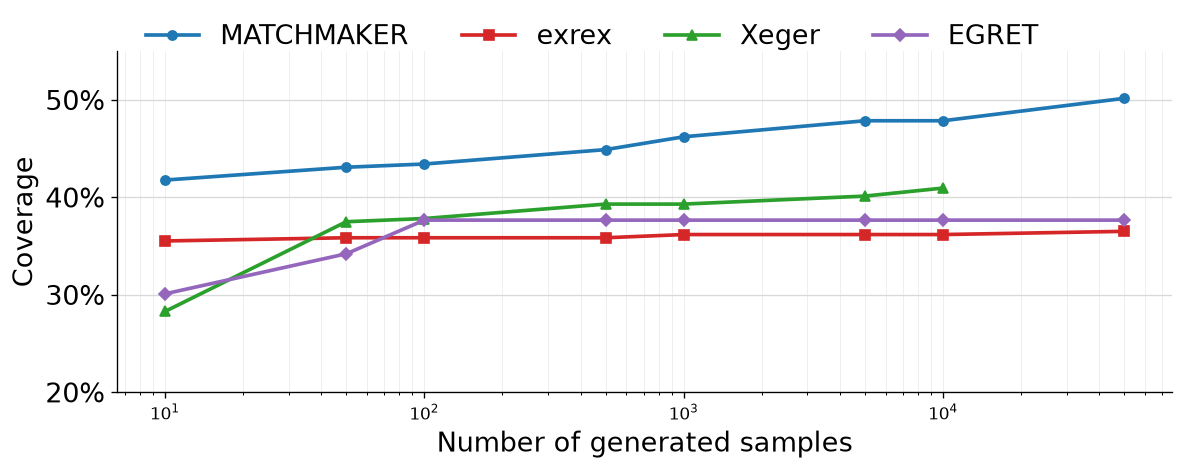

In [22]:
def ordered_tools(rows):
    present = {row["tool"] for row in rows}
    ordered = [tool for tool in TOOL_ORDER if tool in present]
    ordered.extend(sorted(present - set(ordered)))
    return ordered


def metric_title(metric):
    return {
        "code_coverage": "Code coverage",
        "branch_coverage": "Branch coverage",
    }.get(metric, metric.replace("_", " ").title())


def percent_formatter(value, _pos):
    return f"{value:.0f}%"


tools = ordered_tools(rows)
target_label = target_names[0] if len(target_names) == 1 else "multiple targets"

fig_height = 3.8 * len(METRICS)
fig, axes = plt.subplots(len(METRICS), 1, figsize=(10, 4), sharex=True)
if len(METRICS) == 1:
    axes = [axes]

for ax, metric in zip(axes, METRICS):
    for tool in tools:
        tool_rows = [row for row in rows if row["tool"] == tool]
        line_rows = [row for row in tool_rows if (row.get("status") == "ok" or not ONLY_OK_IN_LINES)]
        line_rows = sorted(line_rows, key=lambda row: int(row["samples_per_class"]))

        if line_rows:
            x_values = [int(row["samples_per_class"]) for row in line_rows]
            y_values = [float(row.get(metric, 0.0)) * 100.0 for row in line_rows]
            ax.plot(
                x_values,
                y_values,
                label=TOOL_LABELS.get(tool, tool),
                color=TOOL_COLORS.get(tool),
                marker=TOOL_MARKERS.get(tool, "o"),
                linewidth=2.2,
                markersize=5.5,
            )

        if INCLUDE_ERROR_MARKERS:
            error_rows = sorted(
                [row for row in tool_rows if row.get("error_message")],
                key=lambda row: int(row["samples_per_class"]),
            )
            if error_rows:
                error_x = [int(row["samples_per_class"]) for row in error_rows]
                ax.scatter(
                    error_x,
                    [0.0] * len(error_x),
                    color=TOOL_COLORS.get(tool),
                    marker="x",
                    s=55,
                    linewidths=2,
                    label=TOOL_LABELS.get(tool, tool) if metric == METRICS[0] and not line_rows else None,
                )

    # ax.set_title(metric_title(metric))
    ax.set_ylabel("Coverage", fontsize=16)
    ax.set_ylim(20, 55)
    ax.yaxis.set_major_formatter(FuncFormatter(percent_formatter))
    ax.tick_params(axis="y", labelsize=16)
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.8)
    ax.grid(axis="x", color="#eeeeee", linewidth=0.6, which="both")

axes[-1].set_xscale("log")
axes[-1].set_xlabel("Number of generated samples", fontsize=16)

handles, labels = axes[0].get_legend_handles_labels()
seen = set()
deduped = []
for handle, label in zip(handles, labels):
    if label in seen:
        continue
    seen.add(label)
    deduped.append((handle, label))

handles = [item[0] for item in deduped]
labels = [item[1] for item in deduped]
fig.legend(handles, labels, loc="upper center", ncol=min(4, len(labels)), frameon=False, fontsize=16)

fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

In [21]:
# Quick table for inspecting what each curve is actually using.
print(f"{'Tool':<18} {'n':>8} {'Status':>10} {'Generated':>10} {'+':>8} {'-':>8} {'Code':>8} {'Branch':>8}")
print("-" * 88)
for row in sorted(rows, key=lambda item: (item["tool"], int(item["samples_per_class"]))):
    print(
        f"{row['tool']:<18} {int(row['samples_per_class']):>8} {row.get('status', ''):>10} "
        f"{int(row.get('total_samples', 0)):>10} {int(row.get('positives_generated', 0)):>8} "
        f"{int(row.get('negatives_generated', 0)):>8} "
        f"{float(row.get('code_coverage', 0.0)) * 100:>7.2f}% "
        f"{float(row.get('branch_coverage', 0.0)) * 100:>7.2f}%"
    )

Tool                      n     Status  Generated        +        -     Code   Branch
----------------------------------------------------------------------------------------
EGRET                    10         ok         20       10       10   30.10%   27.68%
EGRET                    50         ok         64       50       14   34.21%   32.59%
EGRET                   100         ok         84       70       14   37.66%   36.61%
EGRET                   500         ok         84       70       14   37.66%   36.61%
EGRET                  1000         ok         84       70       14   37.66%   36.61%
EGRET                  5000         ok         84       70       14   37.66%   36.61%
EGRET                 10000         ok         84       70       14   37.66%   36.61%
EGRET                 50000         ok         84       70       14   37.66%   36.61%
Generex                  10      error          0        0        0    0.00%    0.00%
Generex                  50      error          0  